# Customer Churn Exploratory Data Analysis (EDA)
Complete analysis of customer churn patterns and relationships

## 1. Import Required Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore the Dataset

In [2]:
# Load data
csv_path = Path('Customer Churn.csv')
df = pd.read_csv(csv_path)

# Display basic information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
df.head()

DATASET OVERVIEW
Shape: 3150 rows, 14 columns

Memory Usage: 0.34 MB

FIRST 5 ROWS


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


## 3. Check Data Quality

In [3]:
# Data types
print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

# Null values
print("\n" + "="*60)
print("NULL VALUES")
print("="*60)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No null values!")
print(f"\nTotal null values: {df.isnull().sum().sum()}")


DATA TYPES
Call  Failure                int64
Complains                    int64
Subscription  Length         int64
Charge  Amount               int64
Seconds of Use               int64
Frequency of use             int64
Frequency of SMS             int64
Distinct Called Numbers      int64
Age Group                    int64
Tariff Plan                  int64
Status                       int64
Age                          int64
Customer Value             float64
Churn                        int64
dtype: object

NULL VALUES
No null values!

Total null values: 0


## 4. Statistical Summary

In [4]:
# Statistical summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
df.describe()


STATISTICAL SUMMARY


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


## 5. Generate Correlation Heatmap

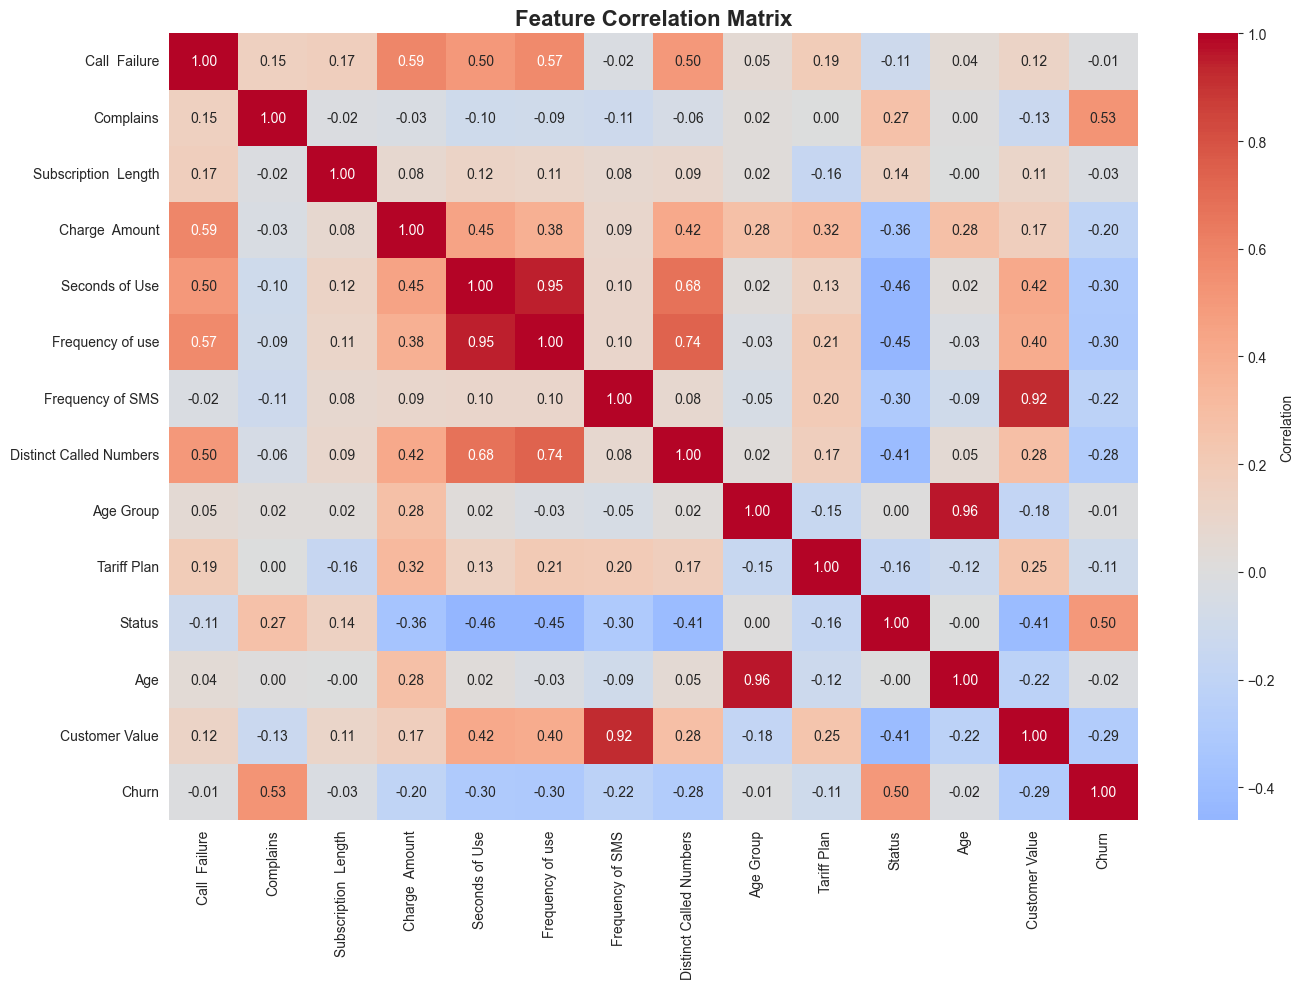


FEATURES MOST CORRELATED WITH CHURN
Churn                      1.000000
Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


In [5]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print strongest correlations with Churn
print("\n" + "="*60)
print("FEATURES MOST CORRELATED WITH CHURN")
print("="*60)
churn_corr = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(churn_corr)

## 6. Analyze Churn Distribution

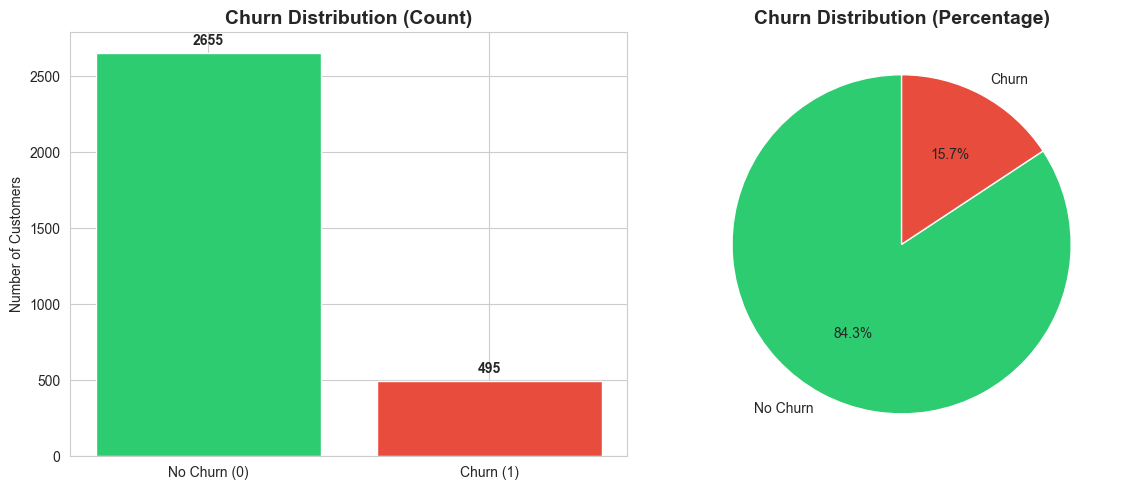


CHURN STATISTICS
Total Customers: 3150
Customers Retained: 2655 (84.29%)
Customers Churned: 495 (15.71%)


In [6]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
churn_pct = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(churn_pct.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CHURN STATISTICS")
print("="*60)
print(f"Total Customers: {len(df)}")
print(f"Customers Retained: {(df['Churn'] == 0).sum()} ({(df['Churn'] == 0).sum()/len(df)*100:.2f}%)")
print(f"Customers Churned: {(df['Churn'] == 1).sum()} ({(df['Churn'] == 1).sum()/len(df)*100:.2f}%)")

## 7. Compare Churn vs Age

C:\Users\adnan\AppData\Local\Temp\ipykernel_21472\1637699588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Age', palette=['#2ecc71', '#e74c3c'])


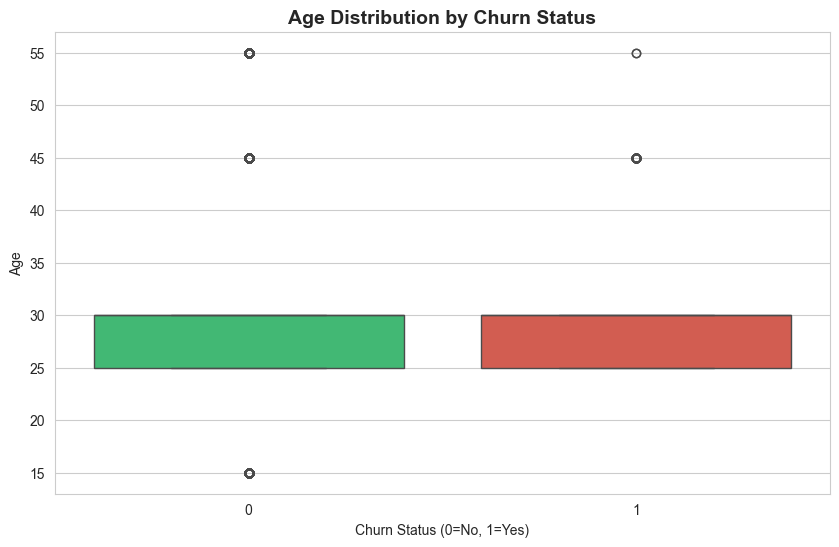


AGE STATISTICS BY CHURN STATUS
        count       mean       std   min   25%   50%   75%   max
Churn                                                           
0      2655.0  31.065913  9.147610  15.0  25.0  30.0  30.0  55.0
1       495.0  30.636364  6.886081  25.0  25.0  30.0  30.0  55.0


In [7]:
# Age vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='Age', palette=['#2ecc71', '#e74c3c'])
plt.title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No, 1=Yes)')
plt.ylabel('Age')
plt.show()

# Statistics
print("\n" + "="*60)
print("AGE STATISTICS BY CHURN STATUS")
print("="*60)
print(df.groupby('Churn')['Age'].describe())

## 8. Compare Churn vs Customer Value

C:\Users\adnan\AppData\Local\Temp\ipykernel_21472\3574219980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Customer Value', palette=['#2ecc71', '#e74c3c'])


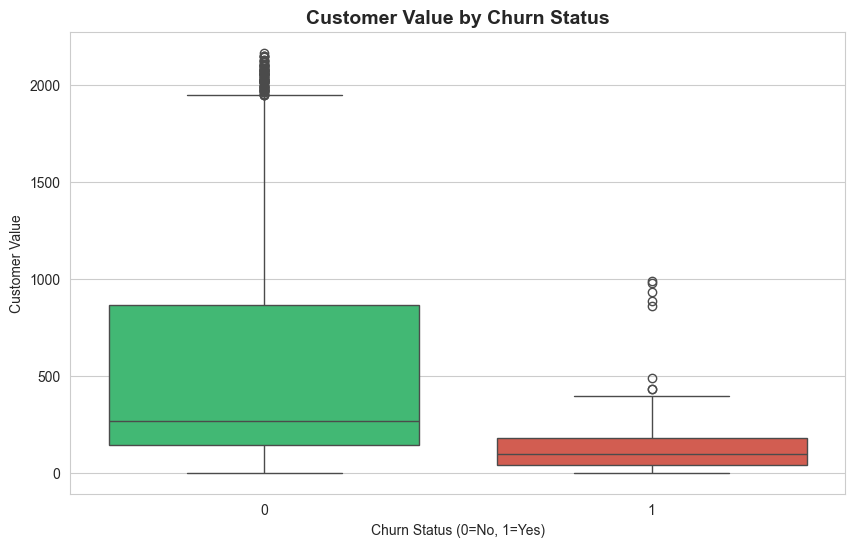


CUSTOMER VALUE STATISTICS BY CHURN STATUS
        count        mean         std  min      25%     50%       75%  \
Churn                                                                   
0      2655.0  535.511501  536.214629  0.0  142.065  268.07  864.5475   
1       495.0  124.811414  129.429850  0.0   38.375   96.84  181.3225   

            max  
Churn            
0      2165.280  
1       987.255  


In [8]:
# Customer Value vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='Customer Value', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Value by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No, 1=Yes)')
plt.ylabel('Customer Value')
plt.show()

# Statistics
print("\n" + "="*60)
print("CUSTOMER VALUE STATISTICS BY CHURN STATUS")
print("="*60)
print(df.groupby('Churn')['Customer Value'].describe())

## 9. Compare Churn vs Usage (Seconds of Use)

C:\Users\adnan\AppData\Local\Temp\ipykernel_21472\1453908809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Seconds of Use', palette=['#2ecc71', '#e74c3c'])


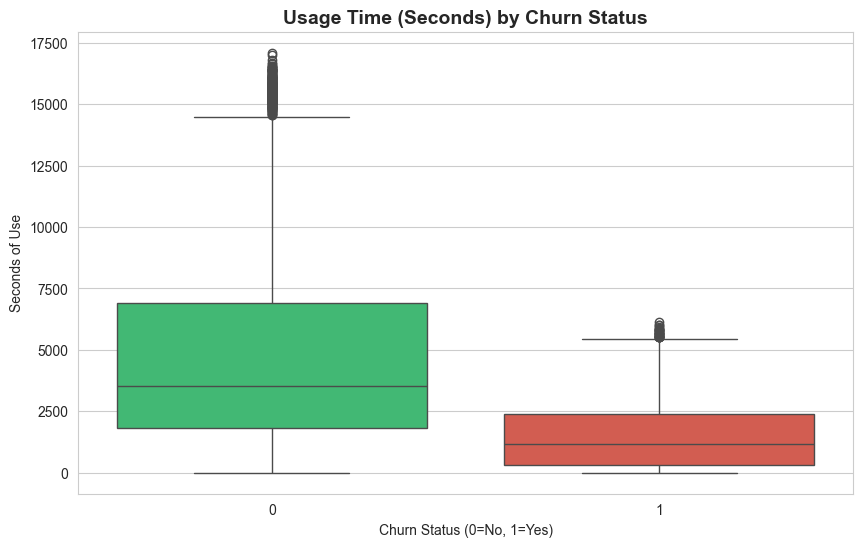


USAGE STATISTICS BY CHURN STATUS
        count         mean          std  min     25%     50%     75%      max
Churn                                                                        
0      2655.0  5014.224105  4312.742630  0.0  1819.0  3530.0  6892.5  17090.0
1       495.0  1566.632323  1539.203365  0.0   318.0  1182.0  2391.5   6123.0


In [9]:
# Usage vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='Seconds of Use', palette=['#2ecc71', '#e74c3c'])
plt.title('Usage Time (Seconds) by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No, 1=Yes)')
plt.ylabel('Seconds of Use')
plt.show()

# Statistics
print("\n" + "="*60)
print("USAGE STATISTICS BY CHURN STATUS")
print("="*60)
print(df.groupby('Churn')['Seconds of Use'].describe())

## 10. Analyze Charge Amount vs Usage

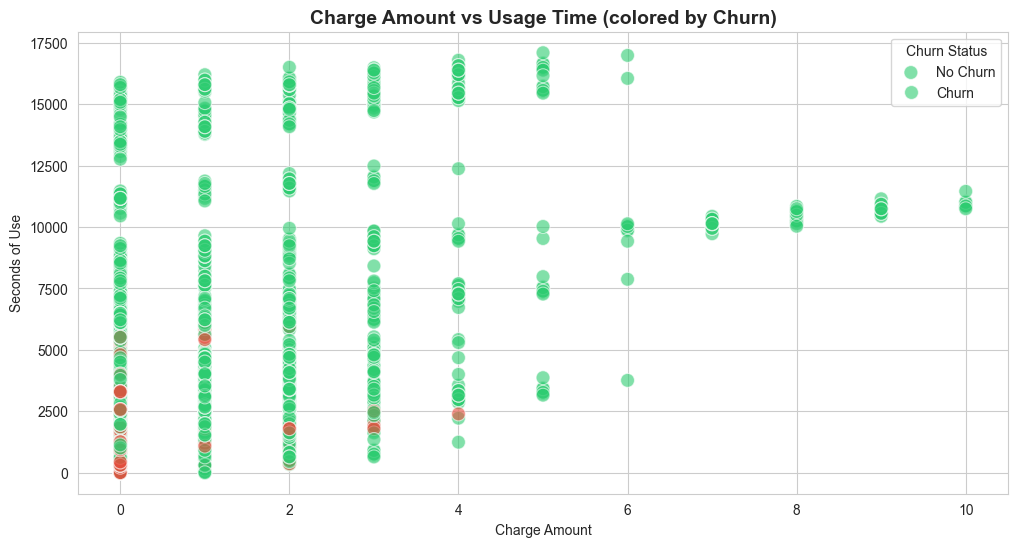

In [10]:
# Scatter plot: Charge Amount vs Usage
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Charge  Amount', y='Seconds of Use', hue='Churn',
                palette=['#2ecc71', '#e74c3c'], alpha=0.6, s=100)
plt.title('Charge Amount vs Usage Time (colored by Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Charge Amount')
plt.ylabel('Seconds of Use')
plt.legend(['No Churn', 'Churn'], title='Churn Status')
plt.show()

## 11. Additional Feature Analysis

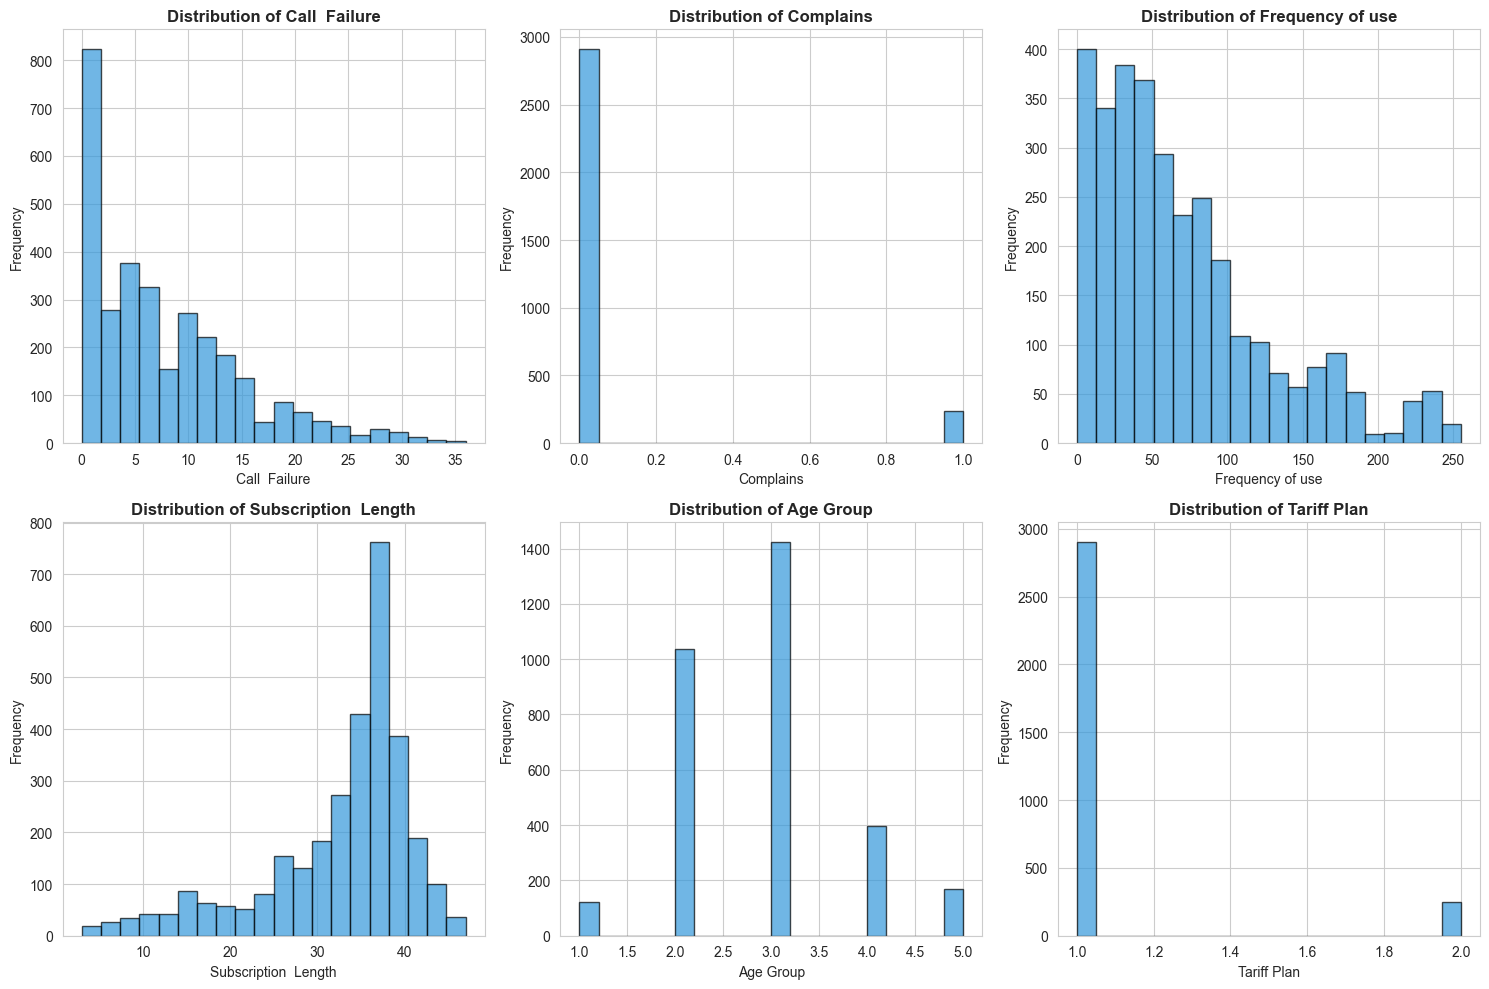

In [11]:
# Distribution of key features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Call  Failure', 'Complains', 'Frequency of use', 'Subscription  Length', 'Age Group', 'Tariff Plan']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(df[feature], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 12. Churn vs Call Failure and Complaints

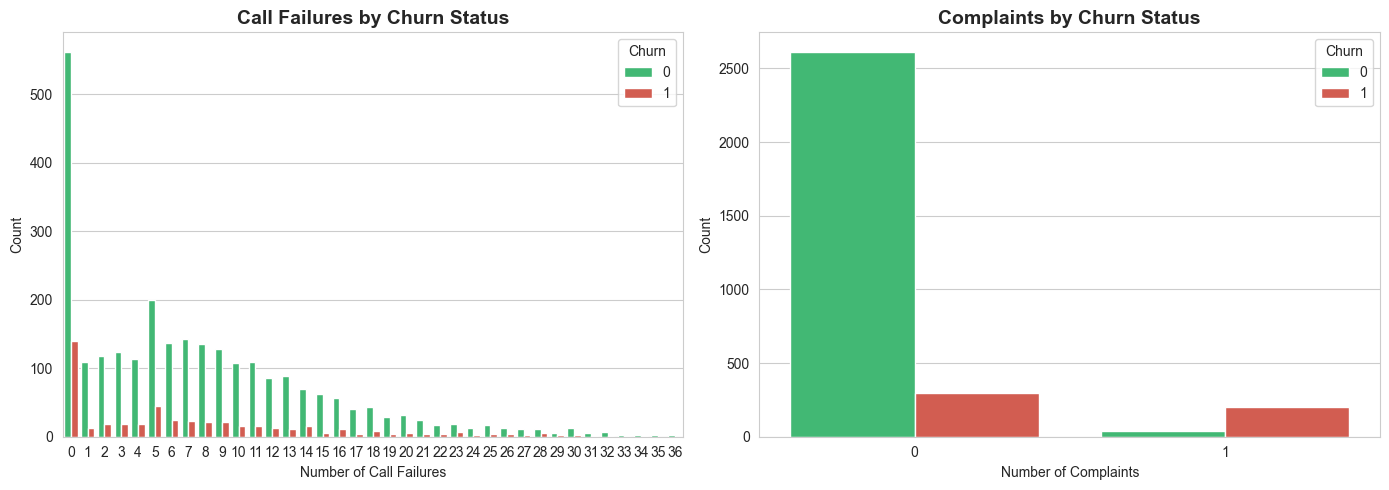


CHURN RATE BY CALL FAILURES
               count  sum   mean
Call  Failure                   
0                702  140  0.199
1                121   12  0.099
2                137   19  0.139
3                141   18  0.128
4                133   19  0.143
5                244   45  0.184
6                161   24  0.149
7                166   23  0.139
8                156   21  0.135
9                149   21  0.141
10               124   16  0.129
11               125   16  0.128
12                97   12  0.124
13                99   11  0.111
14                85   15  0.176
15                69    6  0.087
16                67   11  0.164
17                45    4  0.089
18                53    9  0.170
19                33    4  0.121
20                37    6  0.162
21                29    4  0.138
22                21    4  0.190
23                25    7  0.280
24                16    3  0.188
25                21    4  0.190
26                17    4  0.235
27            

In [12]:
# Call Failure vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Call  Failure', hue='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Call Failures by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Call Failures')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='Complains', hue='Churn', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Complaints by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Complaints')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CHURN RATE BY CALL FAILURES")
print("="*60)
print(df.groupby('Call  Failure')['Churn'].agg(['count', 'sum', 'mean']).round(3))

print("\n" + "="*60)
print("CHURN RATE BY COMPLAINTS")
print("="*60)
print(df.groupby('Complains')['Churn'].agg(['count', 'sum', 'mean']).round(3))

## 13. Summary & Key Insights

In [15]:
print("\n" + "="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

churn_rate = (df['Churn'] == 1).sum() / len(df) * 100
print(f"\n1. Overall Churn Rate: {churn_rate:.2f}%")

# Correlation with churn
corr_with_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(f"\n2. Top 3 features correlated with Churn:")
for i, (feature, corr) in enumerate(corr_with_churn.iloc[1:4].items(), 1):
    print(f"   {i}. {feature}: {corr:.3f}")

# Churn by complaint status
churn_with_complaints = df[df['Complains'] > 0]['Churn'].mean() * 100
churn_no_complaints = df[df['Complains'] == 0]['Churn'].mean() * 100
print(f"\n3. Churn Rate:")
print(f"   - Customers with complaints: {churn_with_complaints:.2f}%")
print(f"   - Customers without complaints: {churn_no_complaints:.2f}%")

print(f"\n4. Average Customer Value:")
print(f"   - Retained customers: ${df[df['Churn']==0]['Customer Value'].mean():.2f}")
print(f"   - Churned customers: ${df[df['Churn']==1]['Customer Value'].mean():.2f}")

print(f"\n5. Average Usage (Seconds):")
print(f"   - Retained customers: {df[df['Churn']==0]['Seconds of Use'].mean():.0f}")
print(f"   - Churned customers: {df[df['Churn']==1]['Seconds of Use'].mean():.0f}")

print("\n" + "="*60)



KEY INSIGHTS FROM EDA

1. Overall Churn Rate: 15.71%

2. Top 3 features correlated with Churn:
   1. Complains: 0.532
   2. Status: 0.499
   3. Call  Failure: -0.009

3. Churn Rate:
   - Customers with complaints: 82.99%
   - Customers without complaints: 10.14%

4. Average Customer Value:
   - Retained customers: $535.51
   - Churned customers: $124.81

5. Average Usage (Seconds):
   - Retained customers: 5014
   - Churned customers: 1567

